# 🌲 Random Forest Regression Tutorial for Turbofan Engine RUL Prediction

## Learning Objectives

By the end of this tutorial, you will:
- Understand what Random Forest is and how it works
- Learn about decision trees and ensemble methods
- Understand key hyperparameters (n_estimators, max_depth, min_samples_split)
- Learn about feature importance in Random Forest
- Train and evaluate a Random Forest model
- Compare Random Forest with Linear Regression and SVR
- Visualize predictions and feature importance

---

## What is Random Forest?

**Random Forest** is a powerful **ensemble learning** algorithm that combines multiple **decision trees** to make predictions.

### The Basic Idea:

Imagine asking 100 experts (trees) to predict something, then taking the **average** of their predictions. That's Random Forest!

### Key Concepts:

#### 1. Decision Trees:

A **decision tree** is like a flowchart that:
- Asks questions about features (e.g., "Is temperature > 600?")
- Splits data based on answers
- Makes predictions at the leaves (end nodes)

**Example Decision Tree for RUL Prediction:**
```
                    Is T30 > 1500?
                   /              \
                 Yes              No
                 /                  \
        Is time > 100?        Is P30 > 550?
           /    \                  /    \
         Yes    No              Yes    No
         /      \                /      \
      RUL=20   RUL=50        RUL=80   RUL=120
```

#### 2. Ensemble Learning:

**Ensemble** = Combining multiple models for better predictions

**Why it works:**
- Individual trees may make mistakes
- But they make **different** mistakes
- Averaging reduces errors (wisdom of the crowd!)

#### 3. Random Forest Algorithm:

1. **Create many trees** (e.g., 100 trees)
2. **Each tree sees different data** (bootstrap sampling)
3. **Each tree uses different features** (random feature selection)
4. **Train each tree independently**
5. **Average predictions** from all trees

### Why "Random"?

Random Forest uses **two types of randomness**:

1. **Bootstrap Aggregating (Bagging)**:
   - Each tree trains on a **random sample** of data (with replacement)
   - Some data points appear multiple times, some not at all
   - This creates diversity among trees

2. **Random Feature Selection**:
   - At each split, tree considers only a **random subset** of features
   - Prevents trees from being too similar
   - Default: √(total_features) features per split

### Advantages of Random Forest:

✅ **Handles non-linear relationships**: No need for feature transformations
✅ **Feature importance**: Automatically identifies important features
✅ **Robust to outliers**: Less sensitive than linear models
✅ **No scaling needed**: Works with raw features
✅ **Handles missing values**: Can work with incomplete data
✅ **Fast training**: Parallelizable (trees train independently)
✅ **Good default**: Works well out-of-the-box

### Disadvantages:

❌ **Less interpretable**: Harder to understand than linear models
❌ **Memory intensive**: Stores all trees
❌ **Can overfit**: With too many trees or too deep trees
❌ **Slower prediction**: Need to run through all trees

### How Random Forest Makes Predictions:

For **regression** (predicting RUL):
1. Each tree makes a prediction
2. Take the **average** of all tree predictions
3. This is the final prediction

**Example:**
- Tree 1 predicts: 85 cycles
- Tree 2 predicts: 92 cycles
- Tree 3 predicts: 88 cycles
- ...
- Tree 100 predicts: 90 cycles
- **Final prediction = Average = 88.5 cycles**

---

## Our Goal: Predict RUL (Remaining Useful Life)

We want to predict **how many cycles** an engine has left before it fails, using Random Forest.

Random Forest is excellent for this because:
- Can capture complex, non-linear relationships between sensors and RUL
- Automatically finds which sensors are most important
- Handles interactions between features automatically
- Works well with many features (we have 24 features)

## Step 1: Import Required Libraries

Before we start, we need to import the necessary libraries.

### Libraries We'll Use:
- **pandas**: For DataFrames and data manipulation
- **numpy**: For numerical operations
- **matplotlib & seaborn**: For visualizations
- **sklearn**: Scikit-learn - the main machine learning library
  - `RandomForestRegressor`: Our Random Forest model
  - `train_test_split`: To split data into training and validation sets
  - `mean_squared_error`, `mean_absolute_error`, `r2_score`: For evaluation metrics

In [1]:
# Import libraries for data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import time  # To measure training time

# Import machine learning components from scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 Scikit-learn version: {__import__('sklearn').__version__}")

✅ All libraries imported successfully!
📦 Pandas version: 2.3.2
📦 NumPy version: 2.2.6
📦 Scikit-learn version: 1.7.2


## Step 2: Load the Dataset

Let's load our turbofan engine dataset. Random Forest doesn't require feature scaling, but we'll still prepare the data properly.

In [2]:
# Define the path to our dataset
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names
op_settings = ['Altitude', 'Mach', 'TRA']
sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
           'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data from CSV files"""
    train_file = data_path / f'train_{dataset}.csv'
    test_file = data_path / f'test_{dataset}.csv'
    rul_file = data_path / f'RUL_{dataset}.csv'
    
    # Read CSV files (they already have headers)
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    rul_df = pd.read_csv(rul_file)
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """Calculate RUL (Remaining Useful Life) for training data"""
    df = df.copy()
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load data for FD001 dataset
train_df, test_df, rul_df = load_data('FD001')

# Calculate RUL for training data
train_df = calculate_rul_train(train_df)

print("✅ Data loaded successfully!")
print(f"\n📊 Training data shape: {train_df.shape}")
print(f"📊 Test data shape: {test_df.shape}")
print(f"🚁 Number of engines in training: {train_df['unit'].nunique()}")
print(f"🚁 Number of engines in test: {test_df['unit'].nunique()}")

✅ Data loaded successfully!

📊 Training data shape: (20631, 27)
📊 Test data shape: (13096, 26)
🚁 Number of engines in training: 100
🚁 Number of engines in test: 100


## Step 3: Prepare Features and Target

Random Forest doesn't require feature scaling, but we still need to prepare features and target properly.

In [3]:
# Select features (X) - everything except unit and RUL
feature_columns = op_settings + sensors + ['time']

# Prepare training features (X) and target (y)
X_train = train_df[feature_columns].copy()
y_train = train_df['RUL'].copy()

# Prepare test data - get last timestep for each engine
test_last_indices = test_df.groupby('unit')['time'].idxmax().values
X_test = test_df.loc[test_last_indices, feature_columns].reset_index(drop=True)
y_test = rul_df['RUL'].values

print("✅ Features and target prepared!")
print(f"\n📊 Training Features shape: {X_train.shape}")
print(f"   - Number of samples: {X_train.shape[0]:,}")
print(f"   - Number of features: {X_train.shape[1]}")
print(f"\n📊 Test Features shape: {X_test.shape}")
print(f"\n💡 Note: Random Forest doesn't require feature scaling!")

✅ Features and target prepared!

📊 Training Features shape: (20631, 25)
   - Number of samples: 20,631
   - Number of features: 25

📊 Test Features shape: (100, 25)

💡 Note: Random Forest doesn't require feature scaling!


In [4]:
# Split training data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    random_state=42
)

print("✅ Data split successfully!")
print(f"\n📊 Training set: {X_train_split.shape[0]:,} samples")
print(f"📊 Validation set: {X_val_split.shape[0]:,} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")

✅ Data split successfully!

📊 Training set: 16,504 samples
📊 Validation set: 4,127 samples
📊 Test set: 100 samples


## Step 4: Understanding Random Forest Hyperparameters

Random Forest has several important hyperparameters. Understanding these helps you tune the model!

### Key Hyperparameters:

#### 1. **n_estimators** - Number of Trees

**What it does**: Controls how many decision trees are in the forest

**Values**:
- **Small** (e.g., 10, 50):
  - Faster training
  - Less accurate
  - More variance (predictions vary more)

- **Large** (e.g., 100, 200, 500):
  - Slower training
  - More accurate (up to a point)
  - Less variance (more stable predictions)
  - Diminishing returns after ~200 trees

**Default**: n_estimators=100

**Rule of thumb**: More trees = better, but slower. 100-200 is usually good.

#### 2. **max_depth** - Maximum Tree Depth

**What it does**: Maximum depth of each decision tree

**Values**:
- **None** (unlimited):
  - Trees grow until all leaves are pure
  - Can overfit
  - Very complex trees

- **Small** (e.g., 5, 10):
  - Shallow trees
  - Simpler model
  - May underfit
  - Faster training

- **Medium** (e.g., 15, 20):
  - Balanced complexity
  - Good default choice

**Default**: max_depth=None (unlimited)

#### 3. **min_samples_split** - Minimum Samples to Split

**What it does**: Minimum number of samples required to split a node

**Values**:
- **Small** (e.g., 2, 5):
  - Trees can split more
  - More complex trees
  - May overfit

- **Large** (e.g., 20, 50):
  - Trees split less
  - Simpler trees
  - May underfit

**Default**: min_samples_split=2

#### 4. **min_samples_leaf** - Minimum Samples in Leaf

**What it does**: Minimum number of samples required in a leaf node

**Values**:
- **Small** (e.g., 1, 5):
  - Smaller leaves
  - More detailed splits
  - May overfit

- **Large** (e.g., 10, 20):
  - Larger leaves
  - Smoother predictions
  - Less overfitting

**Default**: min_samples_leaf=1

#### 5. **max_features** - Features per Split

**What it does**: Number of features to consider when looking for best split

**Values**:
- **'sqrt'**: √(total_features) - Good default for regression
- **'log2'**: log₂(total_features)
- **Integer**: Exact number (e.g., 5, 10)
- **Float**: Fraction (e.g., 0.5 = 50% of features)
- **None**: All features (defeats randomness!)

**Default**: max_features='sqrt'

**Why it matters**: More randomness = more diverse trees = better ensemble

#### 6. **random_state** - Random Seed

**What it does**: Controls randomness for reproducibility

**Values**: Any integer (e.g., 42)

**Why it matters**: Same seed = same results (important for experiments!)

### Summary Table:

| Hyperparameter | Low Value | High Value | Effect |
|---------------|-----------|------------|--------|
| **n_estimators** | Few trees, fast | Many trees, accurate | Number of models |
| **max_depth** | Simple trees | Complex trees | Tree complexity |
| **min_samples_split** | More splits | Fewer splits | Overfitting control |
| **min_samples_leaf** | Small leaves | Large leaves | Smoothness |
| **max_features** | More random | Less random | Tree diversity |

### How to Choose Hyperparameters?

1. **Start with defaults**: Usually work well!
2. **Increase n_estimators**: If you have time, more trees = better
3. **Limit max_depth**: Prevent overfitting (e.g., 15-20)
4. **Tune min_samples_split/leaf**: Control overfitting
5. **Use GridSearchCV**: Automatically find best combination

## Step 5: Create and Train Random Forest Model

Let's create a Random Forest model with default parameters first, then we'll tune it.

In [5]:
# Create Random Forest model with default parameters
print("🌲 Creating Random Forest model...")
print("=" * 80)

# Default Random Forest
# n_estimators=100: 100 trees
# max_depth=None: Unlimited depth
# random_state=42: For reproducibility
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1  # Use all CPU cores for faster training
)

print("✅ Model created!")
print(f"\n📝 Model parameters:")
print(f"   Number of trees: {rf_model.n_estimators}")
print(f"   Max depth: {rf_model.max_depth}")
print(f"   Min samples split: {rf_model.min_samples_split}")
print(f"   Min samples leaf: {rf_model.min_samples_leaf}")
print(f"   Max features: {rf_model.max_features}")

🌲 Creating Random Forest model...
✅ Model created!

📝 Model parameters:
   Number of trees: 100
   Max depth: None
   Min samples split: 2
   Min samples leaf: 1
   Max features: sqrt


In [6]:
# Train the model
print("\n🚀 Training Random Forest model...")
print("⚠️  This may take a minute or two (training 100 trees)...")
print("=" * 80)

start_time = time.time()
rf_model.fit(X_train_split, y_train_split)
training_time = time.time() - start_time

print(f"\n✅ Model trained successfully in {training_time:.2f} seconds!")
print(f"\n📊 Model Information:")
print(f"   Number of trees: {rf_model.n_estimators}")
print(f"   Total features: {rf_model.n_features_in_}")
print(f"   Features per split: {rf_model.max_features}")

# Check average tree depth
avg_depth = np.mean([tree.tree_.max_depth for tree in rf_model.estimators_])
print(f"   Average tree depth: {avg_depth:.1f}")


🚀 Training Random Forest model...
⚠️  This may take a minute or two (training 100 trees)...

✅ Model trained successfully in 0.64 seconds!

📊 Model Information:
   Number of trees: 100
   Total features: 25
   Features per split: sqrt
   Average tree depth: 34.4


## Step 6: Understanding Feature Importance

One of the great advantages of Random Forest is that it automatically calculates **feature importance**!

### What is Feature Importance?

Feature importance measures **how much each feature contributes** to predictions.

### How Random Forest Calculates It:

1. For each tree, measure how much each feature **reduces impurity** (variance for regression)
2. Average across all trees
3. Normalize so sum = 1.0

### Interpretation:

- **High importance** (e.g., 0.15): Feature is used often and reduces error significantly
- **Low importance** (e.g., 0.01): Feature is rarely used or doesn't help much
- **Zero importance**: Feature is never used

### Why It's Useful:

- **Feature selection**: Remove unimportant features
- **Understanding**: See what drives predictions
- **Domain knowledge**: Validate with expert knowledge

In [7]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("📊 Feature Importance (Top 15):")
print("=" * 80)
print(feature_importance.head(15).to_string(index=False))

print(f"\n💡 Total importance: {feature_importance['Importance'].sum():.4f}")
print(f"   (Should be close to 1.0)")

📊 Feature Importance (Top 15):
Feature  Importance
   time    0.268135
    T50    0.111624
   Ps30    0.098381
    phi    0.073823
    P30    0.063394
    BPR    0.058793
     Nc    0.049287
    W32    0.045403
    NRc    0.041979
    W31    0.038363
    T24    0.029121
    T30    0.027267
    NRf    0.026304
htBleed    0.022307
     Nf    0.017059

💡 Total importance: 1.0000
   (Should be close to 1.0)


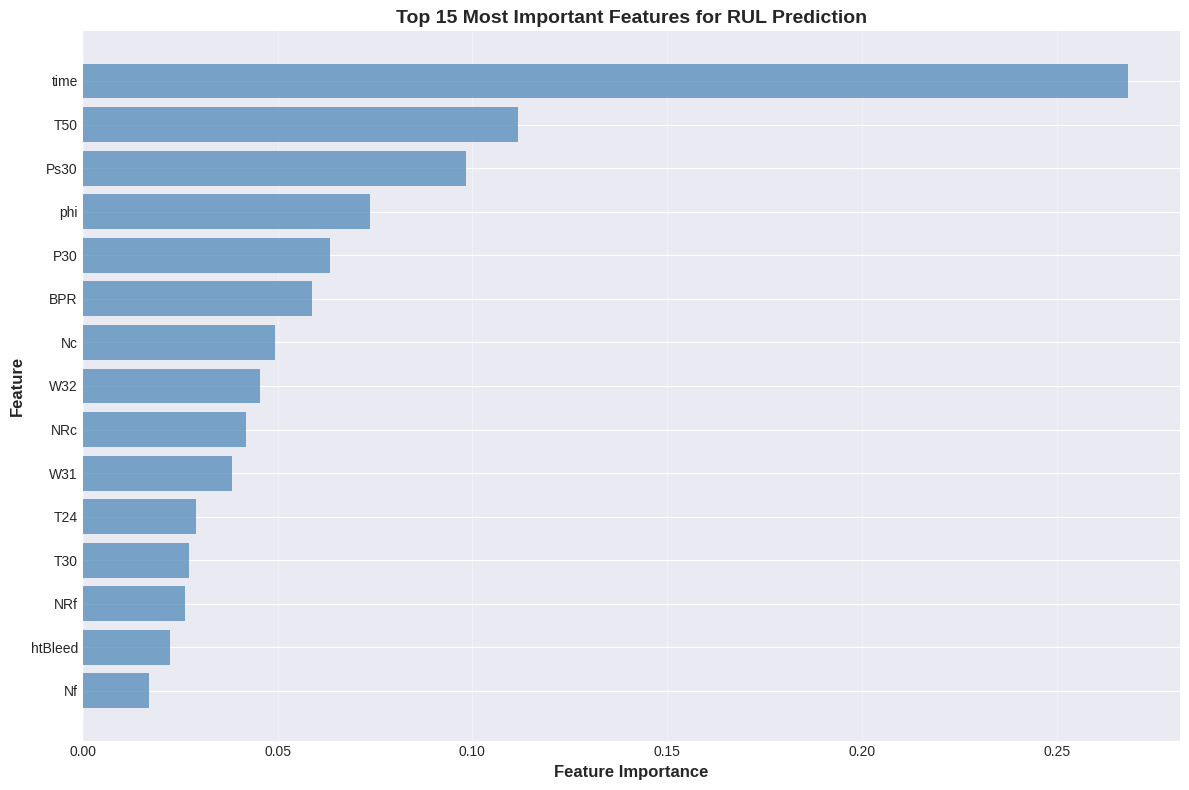

✅ Feature importance visualization created!

💡 Interpretation:
   - Features at top are most important for predicting RUL
   - These features are used most often in tree splits
   - You could remove low-importance features to simplify the model


In [8]:
# Visualize feature importance
plt.figure(figsize=(12, 8))

# Get top 15 features
top_features = feature_importance.head(15)

plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features for RUL Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Show most important at top
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✅ Feature importance visualization created!")
print("\n💡 Interpretation:")
print("   - Features at top are most important for predicting RUL")
print("   - These features are used most often in tree splits")
print("   - You could remove low-importance features to simplify the model")

## Step 7: Make Predictions

Now let's use the trained model to make predictions!

In [9]:
# Make predictions on all datasets
print("🔮 Making predictions...")

# Training set predictions
y_train_pred = rf_model.predict(X_train_split)

# Validation set predictions
y_val_pred = rf_model.predict(X_val_split)

# Test set predictions
y_test_pred = rf_model.predict(X_test)

print("✅ Predictions made successfully!")
print(f"\n📊 Prediction shapes:")
print(f"   Training: {y_train_pred.shape}")
print(f"   Validation: {y_val_pred.shape}")
print(f"   Test: {y_test_pred.shape}")

print(f"\n📊 Sample predictions (first 5 test samples):")
print(f"   Actual RUL:    {y_test[:5]}")
print(f"   Predicted RUL: {y_test_pred[:5].round(2)}")
print(f"   Errors:        {(y_test[:5] - y_test_pred[:5]).round(2)}")

🔮 Making predictions...
✅ Predictions made successfully!

📊 Prediction shapes:
   Training: (16504,)
   Validation: (4127,)
   Test: (100,)

📊 Sample predictions (first 5 test samples):
   Actual RUL:    [112  98  69  82  91]
   Predicted RUL: [176.35 160.69  61.04  78.39 106.42]
   Errors:        [-64.35 -62.69   7.96   3.61 -15.42]


## Step 8: Evaluate Model Performance

Let's calculate performance metrics and see how well our Random Forest model performs.

In [10]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    """Calculate RMSE, MAE, and R² score"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Calculate metrics for all sets
train_metrics = calculate_metrics(y_train_split, y_train_pred, 'Train')
val_metrics = calculate_metrics(y_val_split, y_val_pred, 'Val')
test_metrics = calculate_metrics(y_test, y_test_pred, 'Test')

# Display results
print("📊 Random Forest Model Performance")
print("=" * 80)
print(f"\n{'Set':<12} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
print("-" * 80)
print(f"{'Training':<12} {train_metrics['RMSE']:<12.2f} {train_metrics['MAE']:<12.2f} {train_metrics['R²']:<12.4f}")
print(f"{'Validation':<12} {val_metrics['RMSE']:<12.2f} {val_metrics['MAE']:<12.2f} {val_metrics['R²']:<12.4f}")
print(f"{'Test':<12} {test_metrics['RMSE']:<12.2f} {test_metrics['MAE']:<12.2f} {test_metrics['R²']:<12.4f}")

print("\n💡 Interpretation:")
print(f"   - RMSE: On average, predictions are off by ~{test_metrics['RMSE']:.1f} cycles")
print(f"   - MAE: Average absolute error is ~{test_metrics['MAE']:.1f} cycles")
if test_metrics['R²'] > 0.7:
    print(f"   - R²: Model explains {test_metrics['R²']*100:.1f}% of variance (Excellent!)")
elif test_metrics['R²'] > 0.5:
    print(f"   - R²: Model explains {test_metrics['R²']*100:.1f}% of variance (Good)")
else:
    print(f"   - R²: Model explains {test_metrics['R²']*100:.1f}% of variance (Needs improvement)")

# Check for overfitting
train_val_gap = train_metrics['R²'] - val_metrics['R²']
if train_val_gap > 0.1:
    print(f"\n⚠️  Warning: Large gap between train ({train_metrics['R²']:.4f}) and val ({val_metrics['R²']:.4f}) R²")
    print("   This suggests overfitting. Consider reducing max_depth or increasing min_samples_split.")
else:
    print(f"\n✅ Good generalization: Train and validation R² are similar (gap = {train_val_gap:.4f})")

📊 Random Forest Model Performance

Set          RMSE         MAE          R²          
--------------------------------------------------------------------------------
Training     13.48        9.41         0.9620      
Validation   35.66        25.42        0.7217      
Test         26.76        19.24        0.5853      

💡 Interpretation:
   - RMSE: On average, predictions are off by ~26.8 cycles
   - MAE: Average absolute error is ~19.2 cycles
   - R²: Model explains 58.5% of variance (Good)

⚠️  Warning: Large gap between train (0.9620) and val (0.7217) R²
   This suggests overfitting. Consider reducing max_depth or increasing min_samples_split.


## Step 9: Visualize Predictions

Let's create visualizations to see how well the model predicts RUL.

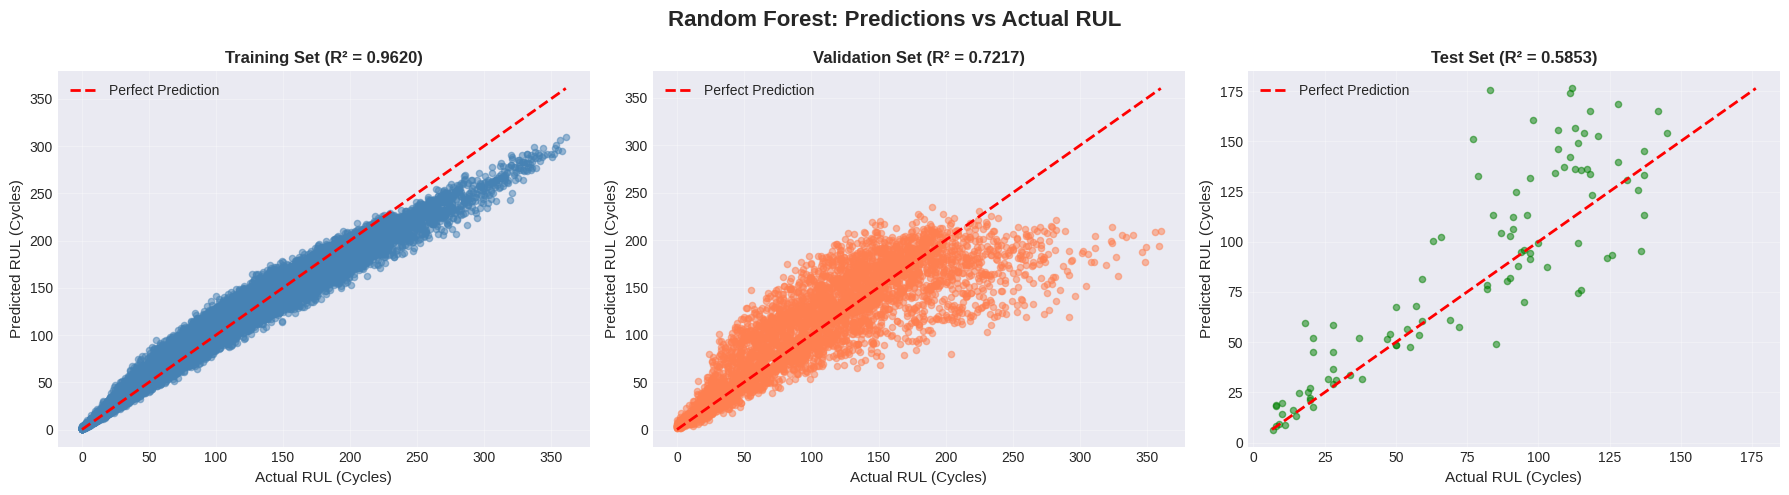

✅ Predictions visualization created!


In [11]:
# Create visualization: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest: Predictions vs Actual RUL', fontsize=16, fontweight='bold')

# Training set
axes[0].scatter(y_train_split, y_train_pred, alpha=0.5, s=20, color='steelblue')
min_val = min(min(y_train_split), min(y_train_pred))
max_val = max(max(y_train_split), max(y_train_pred))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[0].set_title(f'Training Set (R² = {train_metrics["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(y_val_split, y_val_pred, alpha=0.5, s=20, color='coral')
min_val = min(min(y_val_split), min(y_val_pred))
max_val = max(max(y_val_split), max(y_val_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[1].set_title(f'Validation Set (R² = {val_metrics["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='green')
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[2].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[2].set_title(f'Test Set (R² = {test_metrics["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Predictions visualization created!")

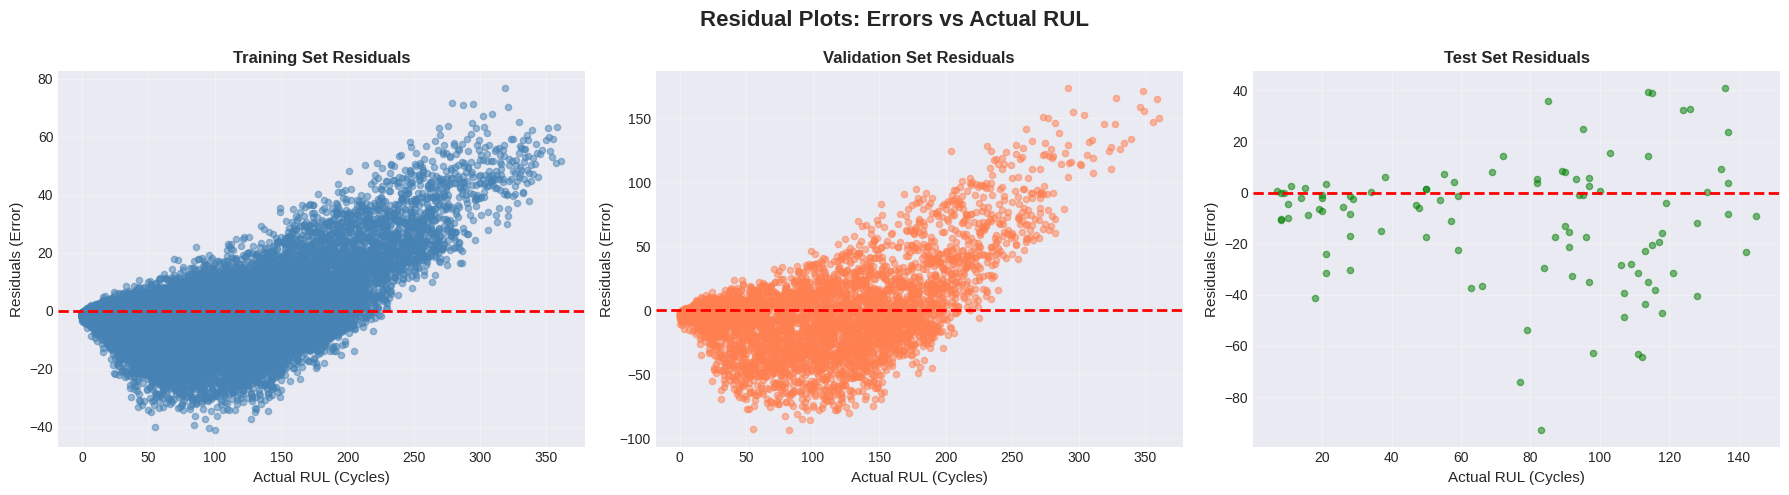

✅ Residual plots created!


In [12]:
# Create residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Plots: Errors vs Actual RUL', fontsize=16, fontweight='bold')

# Calculate residuals
train_residuals = y_train_split - y_train_pred
val_residuals = y_val_split - y_val_pred
test_residuals = y_test - y_test_pred

# Training set residuals
axes[0].scatter(y_train_split, train_residuals, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[0].set_ylabel('Residuals (Error)', fontsize=11)
axes[0].set_title('Training Set Residuals', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Validation set residuals
axes[1].scatter(y_val_split, val_residuals, alpha=0.5, s=20, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[1].set_ylabel('Residuals (Error)', fontsize=11)
axes[1].set_title('Validation Set Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Test set residuals
axes[2].scatter(y_test, test_residuals, alpha=0.5, s=20, color='green')
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[2].set_ylabel('Residuals (Error)', fontsize=11)
axes[2].set_title('Test Set Residuals', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Residual plots created!")

## Step 10: Hyperparameter Tuning (Optional)

Let's tune the hyperparameters to improve performance. We'll use GridSearchCV to find the best combination.

In [13]:
# Hyperparameter tuning for Random Forest
print("🔍 Tuning hyperparameters for Random Forest...")
print("⚠️  This may take several minutes...")
print("=" * 80)

# Define parameter grid (smaller grid for faster tuning)
param_grid = {
    'n_estimators': [50, 100],  # Fewer options for speed
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Perform grid search with cross-validation
print("\n⏳ Running GridSearchCV...")
start_time = time.time()

grid_search = GridSearchCV(
    rf_base, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='r2',  # Use R² as the scoring metric
    n_jobs=-1,  # Use all CPU cores
    verbose=1  # Show progress
)

grid_search.fit(X_train_split, y_train_split)

tuning_time = time.time() - start_time

print(f"\n✅ Hyperparameter tuning completed in {tuning_time/60:.1f} minutes!")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation R²: {grid_search.best_score_:.4f}")

🔍 Tuning hyperparameters for Random Forest...
⚠️  This may take several minutes...

⏳ Running GridSearchCV...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

✅ Hyperparameter tuning completed in 3.5 minutes!

🏆 Best Parameters:
   max_depth: 10
   min_samples_leaf: 4
   min_samples_split: 10
   n_estimators: 100

📊 Best Cross-Validation R²: 0.7265


In [14]:
# Evaluate the tuned model
best_rf = grid_search.best_estimator_

# Make predictions with tuned model
y_test_pred_tuned = best_rf.predict(X_test)

# Calculate metrics
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_test_pred_tuned)
tuned_r2 = r2_score(y_test, y_test_pred_tuned)

print("📊 Tuned Model Performance:")
print("=" * 80)
print(f"   Test RMSE: {tuned_rmse:.2f}")
print(f"   Test MAE: {tuned_mae:.2f}")
print(f"   Test R²: {tuned_r2:.4f}")

print(f"\n📊 Comparison with Default Random Forest:")
print(f"   Default R²: {test_metrics['R²']:.4f}")
print(f"   Tuned R²:   {tuned_r2:.4f}")
improvement = (tuned_r2 - test_metrics['R²']) / test_metrics['R²'] * 100
print(f"   Improvement: {improvement:+.2f}%")

📊 Tuned Model Performance:
   Test RMSE: 25.24
   Test MAE: 18.51
   Test R²: 0.6312

📊 Comparison with Default Random Forest:
   Default R²: 0.5853
   Tuned R²:   0.6312
   Improvement: +7.84%


## 🎓 Summary and Key Takeaways

Congratulations! You've successfully built and evaluated a Random Forest model!

### ✅ What You've Learned:

1. **Random Forest Basics**:
   - Ensemble of decision trees
   - Bootstrap aggregating (bagging)
   - Random feature selection
   - Averages predictions from all trees

2. **Key Hyperparameters**:
   - **n_estimators**: Number of trees (more = better, but slower)
   - **max_depth**: Tree complexity (None = unlimited)
   - **min_samples_split/leaf**: Overfitting control
   - **max_features**: Randomness in feature selection

3. **Feature Importance**:
   - Automatically calculated
   - Shows which features matter most
   - Useful for feature selection

4. **Advantages**:
   - No feature scaling needed
   - Handles non-linear relationships
   - Robust to outliers
   - Good default performance

### 📚 Key Concepts:

- **Ensemble Learning**: Combining multiple models
- **Bootstrap Sampling**: Random sampling with replacement
- **Feature Importance**: How much each feature contributes
- **Overfitting**: Model memorizes training data
- **Hyperparameter Tuning**: Finding best parameters

### 🔄 Random Forest vs Other Models:

| Aspect | Linear Regression | SVR | Random Forest |
|--------|-------------------|-----|---------------|
| **Speed** | Very Fast | Slow | Medium |
| **Scaling** | Helpful | Critical | Not needed |
| **Non-linear** | No | Yes (with kernel) | Yes |
| **Interpretability** | High | Low | Medium |
| **Feature Importance** | No | No | Yes |
| **Overfitting** | Low risk | Medium risk | High risk (if not tuned) |
| **Default Performance** | Good | Good | Excellent |

### 🚀 Next Steps:

1. **Try More Trees**:
   - Increase n_estimators to 200, 500
   - See if performance improves
   - Note: Training time increases

2. **Feature Selection**:
   - Remove low-importance features
   - Retrain with fewer features
   - Compare performance

3. **Try Other Ensemble Methods**:
   - Gradient Boosting (next tutorial!)
   - XGBoost
   - LightGBM

4. **Advanced Techniques**:
   - Use full dataset
   - Cross-validation
   - Ensemble of different models

### 💡 Remember:

- **Random Forest is a great default choice** - works well out-of-the-box
- **Feature importance** helps understand your model
- **More trees = better** (up to a point), but slower
- **Limit max_depth** to prevent overfitting
- **No scaling needed** - works with raw features

---

**Great job completing this tutorial! 🎉🌲**

## 📝 Practice Exercises

Try these exercises to reinforce your learning:

1. **Experiment with n_estimators**:
   - Try 10, 50, 100, 200, 500 trees
   - Plot performance vs number of trees
   - Find the sweet spot (performance vs time)

2. **Experiment with max_depth**:
   - Try max_depth = 5, 10, 15, 20, None
   - Observe training vs validation performance
   - Find balance between accuracy and overfitting

3. **Feature Selection**:
   - Remove features with importance < 0.01
   - Retrain the model
   - Compare performance

4. **Compare with Other Models**:
   - Train Linear Regression and SVR on same data
   - Compare all three models
   - Which performs best?

5. **Full Dataset**:
   - Remove any sampling
   - Train on full dataset
   - See if performance improves

Good luck! 🎯